# Online Shoppers Purchasing Intention
## A guided classification project: raw session data to validated model to API

This notebook is a teaching walkthrough for a binary classification problem. One row is a
summarized online shopping session. The target Revenue says whether the session ended in a
purchase.

The project emphasizes the reasoning behind each step. It is not presented as a production
real-time intervention system: this CSV contains final session summaries rather than
timestamped event snapshots. PageValues is excluded from the deployable model because it may
act as a target proxy.

### Learning goals

1. Frame the prediction problem and identify leakage risks.
2. Inspect a tabular dataset and understand target balance and feature types.
3. Split before fitting learned preprocessing.
4. Build numeric and categorical preprocessing with ColumnTransformer.
5. Compare a baseline, a regularized linear classifier, and a nonlinear tree model.
6. Evaluate an imbalanced task with precision, recall, F1, average precision, ROC AUC, and a
   confusion matrix.
7. Choose a decision threshold using validation data; reserve test data for final evaluation.
8. Explore feature creation, PCA, and L1 feature selection as conditional techniques.
9. Save the same fitted pipeline used by FastAPI.

## 1. Frame the business and ML problem

Question: given a summarized session, estimate whether Revenue=True.

- Observation / row: one online shopping session.
- Target: Revenue, a binary label.
- Task: supervised binary classification.
- Possible use: study which session summaries are associated with purchase outcomes.
- Important limitation: the file has session-level summaries, not event-time snapshots. It
  cannot by itself prove that the model can identify purchase intent early enough to intervene.

The target label is not an input. PageValues is also excluded from the deployed feature set.
UCI describes Page Value as a Google Analytics page-value metric; it can contain information
very close to the transaction outcome. A high score using such a field may reflect a target
proxy rather than useful early intent. Always ask whether a feature is available at the
intended prediction moment.

In [1]:
from pathlib import Path
import os
import sys

# Jupyter may start at its server root or at this project. Find the project without relying
# on a developer-specific absolute path. SHOPPER_PROJECT_DIR can override the search.
project_override = os.environ.get("SHOPPER_PROJECT_DIR")
candidates = []
if project_override:
    candidates.append(Path(project_override).expanduser().resolve())
here = Path.cwd().resolve()
candidates.extend([here, *here.parents])
candidates.extend([
    base / "Feature Engineering/repo/mini_project/exam_score_project/revamped project"
    for base in [here, *here.parents]
])
PROJECT_ROOT = next(
    (path for path in candidates if (path / "src" / "training.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project. Set SHOPPER_PROJECT_DIR to the project directory."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project:", PROJECT_ROOT)

Project: /Users/muhammedfaheem/Desktop/AI_DS/Feature Engineering/repo/mini_project/exam_score_project/revamped project


## 2. Load the data and inspect its shape

Before modeling, confirm that the file loaded as expected, that columns have sensible types,
and that missing values, duplicates, or parsing errors are understood.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.shopper_pipeline import (
    CATEGORICAL_COLUMNS, EXCLUDED_COLUMNS, FEATURE_COLUMNS,
    NUMERIC_COLUMNS, TARGET_COLUMN, build_candidates, build_preprocessor,
)
from src.training import (
    best_f1_threshold, classification_metrics, load_dataset, split_dataset,
)

df = load_dataset()
print(f"Shape: {df.shape[0]:,} rows by {df.shape[1]} columns")
display(df.head())

Shape: 12,330 rows by 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print("Column types:")
display(df.dtypes.rename("dtype").to_frame())
print("Missing values per column:")
display(df.isna().sum().rename("missing").to_frame())
print("Exact duplicate rows:", int(df.duplicated().sum()))
display(df.describe(include="all").T)

Column types:


,dtype
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


Missing values per column:


,missing
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Exact duplicate rows: 125


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


The supplied file has 12,330 rows and no missing values. It contains exact repeated rows.
The training code keeps them: without session IDs or provenance, we cannot tell whether an
exactly repeated summary is a duplicated record or two distinct sessions with the same
observed values. This is a data-quality limitation to revisit if unique session keys become
available.

## 3. Understand the target and class imbalance

A classifier can achieve high accuracy by always predicting the majority class. Inspect the
target distribution before choosing metrics or a decision threshold.

,sessions,fraction
Revenue,,
False,10422,0.845255
True,1908,0.154745


Purchase prevalence: 15.5%


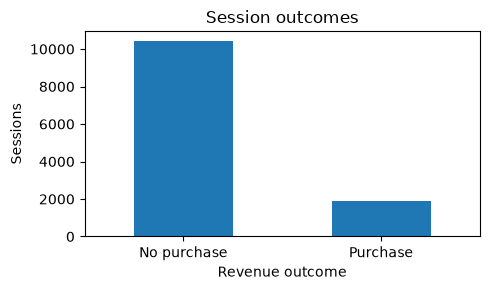

In [4]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_rates = df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
display(pd.DataFrame({"sessions": target_counts, "fraction": target_rates}))
print(f"Purchase prevalence: {df[TARGET_COLUMN].mean():.1%}")

fig, ax = plt.subplots(figsize=(5, 3))
target_counts.rename(index={False: "No purchase", True: "Purchase"}).plot.bar(ax=ax)
ax.set(title="Session outcomes", xlabel="Revenue outcome", ylabel="Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

About 15.5% of rows are positive purchases. Accuracy alone is therefore a poor summary.
Precision asks how many predicted purchases really purchased; recall asks how many purchases
were identified; F1 balances them at one threshold. Average precision summarizes the
precision-recall ranking across thresholds and is useful when the positive class is rare.
ROC AUC describes ranking too, but should be reported with precision-recall metrics.

The right balance depends on the action's cost. If a false alarm is expensive, precision
matters. If missing a purchase opportunity is expensive, recall may matter more.

## 4. Inspect feature roles and the possible target proxy

The dataset contains numeric measurements, category labels, and integer category codes.
A code such as Browser=8 is not four times Browser=2; these codes will be one-hot encoded.
Month, VisitorType, and Weekend are categorical too.

We inspect PageValues to understand why it is omitted. This inspection is not a reason to put
it into the deployed pipeline.

In [5]:
print("Numeric measurements:", NUMERIC_COLUMNS)
print("Categorical columns:", CATEGORICAL_COLUMNS)
print("Excluded from model:", EXCLUDED_COLUMNS)
print("Observed months:", sorted(df["Month"].unique().tolist()))
print("Visitor types:", sorted(df["VisitorType"].unique().tolist()))
display(df.groupby(TARGET_COLUMN)["PageValues"].describe())
display(pd.crosstab(df[TARGET_COLUMN], df["PageValues"].gt(0), normalize="index"))

Numeric measurements: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay']
Categorical columns: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Excluded from model: ['Revenue', 'PageValues']
Observed months: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
Visitor types: ['New_Visitor', 'Other', 'Returning_Visitor']


,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


PageValues,False,True
Revenue,,
False,0.885627,0.114373
True,0.193920,0.806080


PageValues and other session aggregates may only be finalized after browsing is complete.
The original file does not tell us exactly when each column became available. A real-time
deployment needs event timestamps and a feature cutoff. Here we use the remaining session
summaries to learn a classification workflow, and state that the output is a session-level
educational estimate.

## 5. Feature creation: propose, check, and decide

Feature engineering uses domain knowledge to represent patterns a model can learn. We can
derive total pages and total time from the three page groups. These totals are useful for
exploration, but are exact sums of existing columns and may add redundancy. We inspect them
without automatically adding them to the production model.

A proposed feature should be available at prediction time and should improve validation
results or communicate a useful business concept. Do not invent many interactions merely
because one looks correlated with the target.

In [6]:
engineering_demo = df[NUMERIC_COLUMNS].copy()
engineering_demo["TotalPages"] = (
    df["Administrative"] + df["Informational"] + df["ProductRelated"]
)
engineering_demo["TotalPageDuration"] = (
    df["Administrative_Duration"]
    + df["Informational_Duration"]
    + df["ProductRelated_Duration"]
)
display(engineering_demo.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,TotalPages,TotalPageDuration
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,1,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,1,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,10,627.500000


We keep the final feature set simple. A later experiment could compare component features
against totals or add a justified interaction using the same validation discipline. If a
derived feature is selected for serving, implement it inside the saved pipeline so training
and inference cannot drift apart.

## 6. Split before fitting preprocessing

The target is stratified so each partition keeps a similar purchase rate. We use 60% training
to fit candidates, 20% validation to compare candidates and select a threshold, and 20% test
for the final held-out estimate. The split happens before imputers, scalers, and encoders are
fitted. A time-dependent deployment would usually need a chronological split; this dataset
has no actual session date, so we use a stratified session split.

In [7]:
partitions = split_dataset(df)
X_train, y_train = partitions["X_train"], partitions["y_train"]
X_validation, y_validation = partitions["X_validation"], partitions["y_validation"]
X_train_validation = partitions["X_train_validation"]
y_train_validation = partitions["y_train_validation"]
X_test, y_test = partitions["X_test"], partitions["y_test"]

for name, values in [
    ("train", y_train), ("validation", y_validation), ("test", y_test)
]:
    print(f"{name:10s}: {len(values):5,d} rows; purchase rate={values.mean():.3%}")

train     : 7,398 rows; purchase rate=15.477%
validation: 2,466 rows; purchase rate=15.450%
test      : 2,466 rows; purchase rate=15.491%


## 7. Preprocess by column type with ColumnTransformer

Numeric columns receive median imputation and (for logistic regression) standard scaling.
Categorical columns receive most-frequent imputation and one-hot encoding. An unseen
category at prediction time is ignored instead of crashing.

Scaling matters for regularized logistic regression because its penalty acts on coefficient
magnitudes. A duration measured in thousands and a rate between zero and one should not be
penalized as if their raw units were comparable. Random forest uses split thresholds and does
not need standardized numeric values, so its candidate pipeline skips scaling.

These operations are inside each model pipeline, so fitting a candidate learns imputation,
scale, and category vocabulary from training data only.

In [8]:
example_preprocessor = build_preprocessor(scale_numeric=True)
example_preprocessor.fit(X_train, y_train)
print("Transformed training shape:", example_preprocessor.transform(X_train).shape)
print("First transformed feature names:")
print(example_preprocessor.get_feature_names_out()[:20].tolist())

Transformed training shape: (7398, 73)
First transformed feature names:
['numeric__Administrative', 'numeric__Administrative_Duration', 'numeric__Informational', 'numeric__Informational_Duration', 'numeric__ProductRelated', 'numeric__ProductRelated_Duration', 'numeric__BounceRates', 'numeric__ExitRates', 'numeric__SpecialDay', 'categorical__Month_Aug', 'categorical__Month_Dec', 'categorical__Month_Feb', 'categorical__Month_Jul', 'categorical__Month_June', 'categorical__Month_Mar', 'categorical__Month_May', 'categorical__Month_Nov', 'categorical__Month_Oct', 'categorical__Month_Sep', 'categorical__OperatingSystems_1']


## 8. Optional PCA experiment

PCA compresses correlated numeric measurements into principal components. Scaling comes
first because otherwise large-unit features dominate the variance calculation. PCA is not
part of the final model here: it mixes original columns and makes interpretation harder, and
we have not shown that it improves held-out results.

This experiment fits only on training rows and only on numeric page activity columns. It
demonstrates the technique without using validation or test data to learn PCA directions.

In [9]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

page_activity_columns = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
]
pca_experiment = make_pipeline(
    SimpleImputer(strategy="median"), StandardScaler(), PCA()
)
pca_experiment.fit(X_train[page_activity_columns])
explained = pca_experiment.named_steps["pca"].explained_variance_ratio_
display(pd.DataFrame({
    "component": np.arange(1, len(explained) + 1),
    "variance_fraction": explained,
    "cumulative_variance": np.cumsum(explained),
}))

,component,variance_fraction,cumulative_variance
0,1,0.522608,0.522608
1,2,0.166907,0.689515
2,3,0.161145,0.850659
3,4,0.073292,0.923951
4,5,0.054682,0.978633
5,6,0.021367,1.000000


Decision: keep original numeric features for deployment. PCA is useful when dimensionality,
redundancy, or validation performance justifies giving up direct feature meaning. It is not
an automatic step in every project.

## 9. Optional embedded feature-selection experiment

L1-regularized logistic regression can shrink some transformed coefficients to zero.
Selection is sensitive to regularization strength and correlated inputs, so its selected set
can change between samples. This diagnostic is fit on training rows only and does not
silently become the final model.

For a production experiment, tune the penalty inside cross-validation and keep selection
inside the full pipeline. Never select features by looking at test labels.

In [10]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

selection_preprocessor = build_preprocessor(scale_numeric=True)
train_matrix = selection_preprocessor.fit_transform(X_train, y_train)
selector = SelectFromModel(
    LogisticRegression(
        penalty="l1", solver="liblinear", class_weight="balanced",
        C=0.1, max_iter=2000, random_state=42,
    ),
    threshold=1e-6,
)
selector.fit(train_matrix, y_train)
selected_names = selection_preprocessor.get_feature_names_out()[selector.get_support()]
print(f"Selected {len(selected_names)} transformed features:")
print(selected_names.tolist())

Selected 30 transformed features:
['numeric__Administrative', 'numeric__Administrative_Duration', 'numeric__Informational', 'numeric__ProductRelated', 'numeric__ProductRelated_Duration', 'numeric__BounceRates', 'numeric__ExitRates', 'numeric__SpecialDay', 'categorical__Month_Dec', 'categorical__Month_Feb', 'categorical__Month_Mar', 'categorical__Month_May', 'categorical__Month_Nov', 'categorical__Month_Oct', 'categorical__OperatingSystems_1', 'categorical__OperatingSystems_2', 'categorical__OperatingSystems_3', 'categorical__Browser_2', 'categorical__Browser_10', 'categorical__Region_2', 'categorical__Region_6', 'categorical__Region_9', 'categorical__TrafficType_1', 'categorical__TrafficType_3', 'categorical__TrafficType_6', 'categorical__TrafficType_8', 'categorical__TrafficType_13', 'categorical__TrafficType_20', 'categorical__VisitorType_Returning_Visitor', 'categorical__Weekend_False']


/Users/muhammedfaheem/Desktop/AI_DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/muhammedfaheem/Desktop/AI_DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 10. Establish a naive baseline

DummyClassifier ignores all inputs and predicts the training class prevalence. Its average
precision is a useful ranking reference. Always ask whether a model beats a simple baseline
by an amount that matters, not only whether it runs.

In [11]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
dummy_validation_probabilities = dummy.predict_proba(X_validation)[:, 1]
dummy_metrics = classification_metrics(
    y_validation, dummy_validation_probabilities, threshold=0.5
)
pd.Series(dummy_metrics, name="dummy_validation").to_frame()

,dummy_validation
average_precision,0.154501
roc_auc,0.500000
threshold,0.500000
precision,0.000000
recall,0.000000
f1,0.000000
balanced_accuracy,0.500000
accuracy,0.845499


## 11. Compare candidate models on validation data

We compare balanced logistic regression, a regularized and relatively interpretable model,
with a balanced random forest, a nonlinear comparison. Class weights change the penalty for
mistakes on each class during fitting; they do not create more independent positive examples.

Average precision selects the model. Then validation predictions select a threshold by
maximum F1. The test set is not used for either choice.

In [12]:
candidate_pipelines = build_candidates()
fitted_candidates = {}
validation_rows = []

for name, candidate in candidate_pipelines.items():
    candidate.fit(X_train, y_train)
    fitted_candidates[name] = candidate
    probabilities = candidate.predict_proba(X_validation)[:, 1]
    metrics = classification_metrics(y_validation, probabilities, threshold=0.5)
    validation_rows.append({"model": name, **metrics})

validation_results = (
    pd.DataFrame(validation_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)
display(validation_results)

,average_precision,roc_auc,threshold,precision,recall,f1,balanced_accuracy,accuracy
model,,,,,,,,
balanced_random_forest,0.343050,0.763946,0.5,0.409283,0.254593,0.313916,0.593723,0.828062
balanced_logistic_regression,0.321779,0.743525,0.5,0.263686,0.758530,0.391334,0.685740,0.635442


In [13]:
selected_name = validation_results["average_precision"].idxmax()
selected_pipeline = fitted_candidates[selected_name]
validation_probabilities = selected_pipeline.predict_proba(X_validation)[:, 1]
decision_threshold = best_f1_threshold(y_validation, validation_probabilities)
selected_validation_metrics = classification_metrics(
    y_validation, validation_probabilities, threshold=decision_threshold
)
print("Selected by validation average precision:", selected_name)
print(f"Validation threshold selected by max F1: {decision_threshold:.4f}")
display(pd.Series(selected_validation_metrics, name="selected validation").to_frame())

Selected by validation average precision: balanced_random_forest
Validation threshold selected by max F1: 0.3191


,selected validation
average_precision,0.343050
roc_auc,0.763946
threshold,0.319146
precision,0.303594
recall,0.643045
f1,0.412458
balanced_accuracy,0.686750
accuracy,0.716951


F1 is one threshold policy, not a universal business objective. If outreach capacity is
limited, a top-k rule may be more useful. If false positives and false negatives have
different costs, calculate expected cost and select a threshold accordingly. No business
cost data was supplied here, so validation max-F1 is a teaching default.

## 12. Final refit and held-out test evaluation

After choosing the model and threshold, refit the selected recipe on train plus validation.
The test set remains untouched until the final evaluation. Report ranking metrics and
threshold-dependent metrics together.

In [14]:
selected_pipeline.fit(X_train_validation, y_train_validation)
test_probabilities = selected_pipeline.predict_proba(X_test)[:, 1]
test_metrics = classification_metrics(
    y_test, test_probabilities, threshold=decision_threshold
)
display(pd.Series(test_metrics, name="held-out test").to_frame())

,held-out test
average_precision,0.363150
roc_auc,0.765050
threshold,0.319146
precision,0.301648
recall,0.623037
f1,0.406490
balanced_accuracy,0.679321
accuracy,0.718167


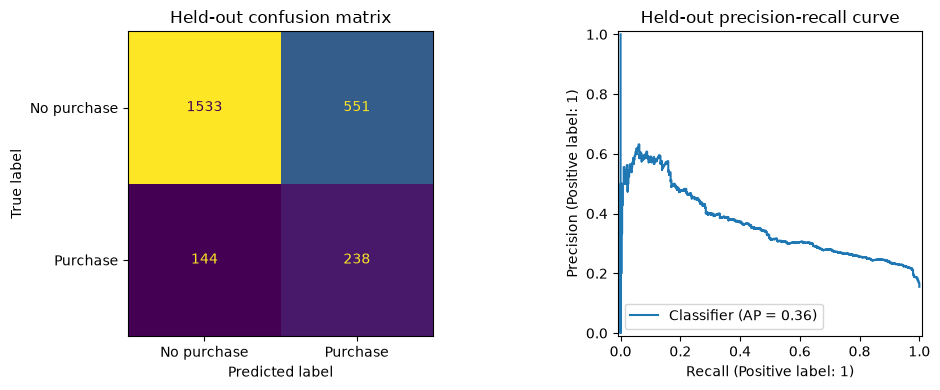

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

test_predictions = (test_probabilities >= decision_threshold).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=["No purchase", "Purchase"],
    colorbar=False, ax=axes[0],
)
axes[0].set_title("Held-out confusion matrix")
PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=axes[1])
axes[1].set_title("Held-out precision-recall curve")
plt.tight_layout()
plt.show()

A confusion matrix makes error types visible. A false positive is a session labeled purchase
that did not purchase; a false negative is a purchase the model missed. Look at both counts
and metric values before deciding whether this operating point is useful.

## 13. Interpretability and limitations

For logistic regression, coefficients describe changes in log odds conditional on other
transformed features; they are not causal effects. Numeric predictors are standardized and
categorical predictors are one-hot indicators. A random forest can represent nonlinear
splits, but does not make causal claims either.

Feature importance describes associations available to this model in this dataset. It does
not show what would happen if a business changed a feature.

In [16]:
if selected_name == "balanced_logistic_regression":
    fitted_preprocessor = selected_pipeline.named_steps["preprocess"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    coefficients = selected_pipeline.named_steps["classifier"].coef_[0]
    coefficient_table = (
        pd.DataFrame({"feature": feature_names, "coefficient_log_odds": coefficients})
        .assign(abs_effect=lambda frame: frame["coefficient_log_odds"].abs())
        .sort_values("abs_effect", ascending=False)
        .drop(columns="abs_effect")
    )
    display(coefficient_table.head(20))
else:
    print(
        "A random forest was selected. Use permutation importance on held-out or "
        "validation rows for a model-agnostic ranking; do not interpret importance as cause."
    )

A random forest was selected. Use permutation importance on held-out or validation rows for a model-agnostic ranking; do not interpret importance as cause.


## 14. Persist the pipeline used by the API

The saved pipeline includes the fitted imputer, scaler where applicable, one-hot category
vocabulary, and classifier. FastAPI accepts raw columns and uses this pipeline rather than
reimplementing preprocessing.

The next cell calls the same deterministic workflow as the command-line training entry
point. It writes the model and a metadata file with validation/test metrics and threshold.

In [17]:
from src.training import train_and_save

metadata = train_and_save()
print("Saved model:", PROJECT_ROOT / "models" / "shopper_purchase_pipeline.joblib")
display(pd.Series(metadata["final_test_metrics"], name="saved model test metrics").to_frame())

Selected model: balanced_random_forest
Decision threshold (validation max F1): 0.3191
Validation metrics: {
  "average_precision": 0.3430501283974736,
  "roc_auc": 0.76394569383863,
  "threshold": 0.3191460816071113,
  "precision": 0.30359355638166047,
  "recall": 0.6430446194225722,
  "f1": 0.41245791245791247,
  "balanced_accuracy": 0.6867501274570895,
  "accuracy": 0.7169505271695052
}
Held-out test metrics: {
  "average_precision": 0.36314983787374017,
  "roc_auc": 0.7650498437358684,
  "threshold": 0.3191460816071113,
  "precision": 0.30164765525982257,
  "recall": 0.6230366492146597,
  "f1": 0.40649017933390263,
  "balanced_accuracy": 0.6793206278702857,
  "accuracy": 0.7181670721816708
}
Saved model: /Users/muhammedfaheem/Desktop/AI_DS/Feature Engineering/repo/mini_project/exam_score_project/revamped project/models/shopper_purchase_pipeline.joblib
Saved metadata: /Users/muhammedfaheem/Desktop/AI_DS/Feature Engineering/repo/mini_project/exam_score_project/revamped project/artifac

,saved model test metrics
average_precision,0.363150
roc_auc,0.765050
threshold,0.319146
precision,0.301648
recall,0.623037
f1,0.406490
balanced_accuracy,0.679321
accuracy,0.718167


## 15. Connect FastAPI and Streamlit

FastAPI validates the 16 model fields and returns purchase probability, a threshold-based
label, threshold, and model version. Revenue is a target and PageValues is excluded; neither
can be submitted as an input. Streamlit is an HTTP client and does not load the model.

Run after training:
- API: uvicorn app.main:app --reload --port 8000
- UI: streamlit run streamlit_app.py
- Browser UI: http://localhost:8501
- API schema: http://localhost:8000/docs

The final project Dockerfile builds one image containing both processes. See README.md for
the full Docker commands and the caveats around the shared parent environment.

## 16. What to carry into another dataset

The transferable workflow is not “always use PCA and Lasso.” It is:
1. Define the row, target, prediction moment, and decision.
2. Inspect quality, feature types, missingness, target balance, and leakage.
3. Split to mimic future examples; keep learned preprocessing inside a pipeline.
4. Compare with a baseline using metrics that reflect the task and error costs.
5. Add transformations only when domain logic and validation justify them.
6. Select models and thresholds on training/validation data; report held-out results.
7. Save the entire fitted pipeline and accept the same raw schema at inference.
8. State what the data cannot support.

For a different target type, change the task, split, estimator, metrics, and API contract.
Keep the reasoning discipline.